In [1]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
df_israel = df[df['job_country'] == 'Israel'].copy()

In [4]:
df_israel['job_posted_month'] = df_israel['job_posted_date'].dt.strftime('%B')
df_israel

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
71,Business Analyst,Business Analyst,"Tel Aviv-Yafo, Israel",via Comeet,Full-time,False,Israel,2023-09-05 13:50:12,False,False,Israel,NaN,NaN,NaN,ironSource,"['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",September
106,Senior Data Analyst,Senior Data Analyst (1541),Israel,via LinkedIn,Full-time,False,Israel,2023-07-13 13:27:00,True,False,Israel,NaN,NaN,NaN,TCM Technologies LTD,['python'],{'programming': ['python']},July
153,Business Analyst,Business Intelligence Analyst (Supply Analytic...,"Tel Aviv-Yafo, Israel",via LinkedIn,Full-time,False,Israel,2023-10-30 13:16:56,False,False,Israel,NaN,NaN,NaN,Agoda,"['sql', 'tableau']","{'analyst_tools': ['tableau'], 'programming': ...",October
331,Data Analyst,Machine Learning Data Analyst,"Tel Aviv-Yafo, Israel",via LinkedIn,Full-time,False,Israel,2023-10-02 13:51:22,False,False,Israel,NaN,NaN,NaN,Hello Heart,"['r', 'python', 'sql', 'pandas', 'numpy']","{'libraries': ['pandas', 'numpy'], 'programmin...",October
592,Data Analyst,דרוש/ה excel data analyst לחברת מאגרי מידע,"Herzliya, Israel",via LinkedIn,Full-time,False,Israel,2023-05-08 13:44:31,True,False,Israel,NaN,NaN,NaN,Pharma14.com,['excel'],{'analyst_tools': ['excel']},May
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785435,Data Scientist,Verification Engineer,"Tel Aviv-Yafo, Israel",via Trabajo.org,Full-time,False,Israel,2023-01-01 07:07:31,True,False,Israel,NaN,NaN,NaN,Amazon,['aws'],{'cloud': ['aws']},January
785574,Data Analyst,Voice of Customer Analyst,"Tel Aviv-Yafo, Israel",via Trabajo.org,Full-time,False,Israel,2023-01-25 06:51:49,True,False,Israel,NaN,NaN,NaN,Wolt,NaN,NaN,January
785581,Software Engineer,Staff DevOps Engineer,"Tel Aviv-Yafo, Israel",via Trabajo.org,Full-time,False,Israel,2023-01-25 06:52:14,False,False,Israel,NaN,NaN,NaN,SailPoint,"['aws', 'windows', 'linux', 'kubernetes', 'jen...","{'cloud': ['aws'], 'os': ['windows', 'linux'],...",January
785619,Software Engineer,Software Engineering Student,"Tel Aviv-Yafo, Israel",via Trabajo.org,Full-time,False,Israel,2023-04-11 06:52:21,False,False,Israel,NaN,NaN,NaN,VAST Data,['linux'],{'os': ['linux']},April


In [13]:
df_israel_pivot = df_israel.pivot_table(index='job_posted_month', columns='job_title_short',aggfunc='size')

In [18]:
df_israel_pivot.reset_index(inplace=True)
df_israel_pivot['month_no'] = pd.to_datetime(df_israel_pivot['job_posted_month'],format='%B').dt.month

df_israel_pivot.set_index('month_no',inplace=True)
df_israel_pivot.sort_index(inplace=True)
df_israel_pivot.set_index('job_posted_month',inplace=True)
df_israel_pivot.drop(columns=['level_0','index'],inplace=True)

df_israel_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,82,37,130,115,92,51,30,32,42,230
February,36,9,94,76,70,21,25,32,25,87
March,38,23,96,80,60,14,18,31,14,74
April,58,26,64,60,58,22,20,17,21,119
May,45,6,72,69,66,10,21,27,19,69
June,39,10,77,60,63,20,17,33,18,52
July,36,8,75,60,56,25,20,32,19,51
August,45,4,64,57,45,24,10,20,18,80
September,20,2,66,40,43,13,9,15,20,33


<Axes: xlabel='job_posted_month'>

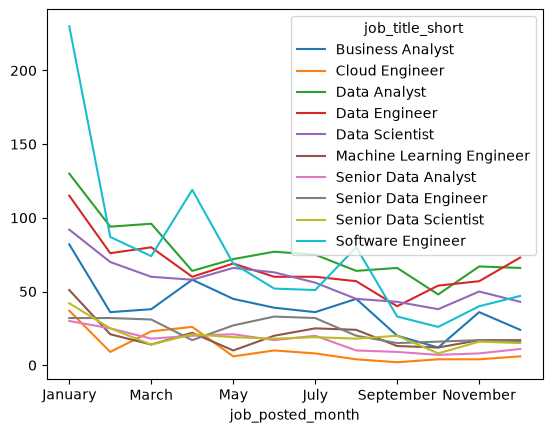

In [19]:
df_israel_pivot.plot(kind='line')

In [22]:
top_3 = df_israel['job_title_short'].value_counts().head(3)
top_3 = top_3.index.tolist()

<Axes: xlabel='job_posted_month'>

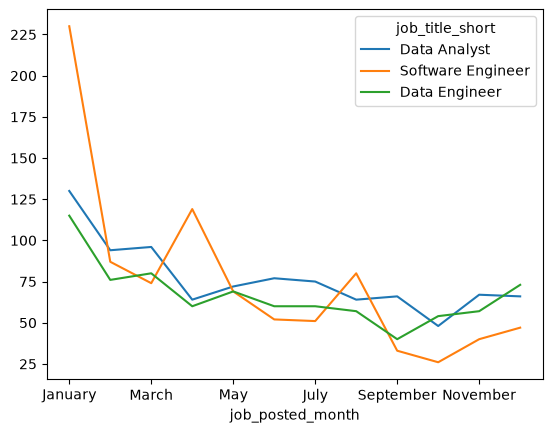

In [23]:
df_israel_pivot[top_3].plot(kind='line')